# DATA 266 - HW2
## Part 1: Embedding-Based Transfer Learning

SID4 = 5996  
SEED = 5996  
SLICE = 996  
HP_ID = 2  
CLS_A = 6  
CLS_B = 2

In [2]:
SID4 = 5996
SEED = 5996
SLICE = 996
HP_ID = 2
CLS_A = 6
CLS_B = 2

import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)

print("SID4 =", SID4)
print("SEED =", SEED)
print("SLICE =", SLICE)
print("HP_ID =", HP_ID)
print("CLS_A =", CLS_A)
print("CLS_B =", CLS_B)

SID4 = 5996
SEED = 5996
SLICE = 996
HP_ID = 2
CLS_A = 6
CLS_B = 2


In [3]:
!pip install -q gensim datasets scikit-learn matplotlib pandas nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 76.9 MB/s eta 0:00:00


In [4]:
import gensim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Gensim version:", gensim.__version__)

Gensim version: 4.4.0


In [5]:
import gensim.downloader as api

pretrained = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [6]:
print("Vocabulary size:", len(pretrained))
print("Embedding dimension:", pretrained.vector_size)

Vocabulary size: 3000000
Embedding dimension: 300


In [7]:
target_words = ["cast", "score", "plot", "screen", "review"]

for word in target_words:
    print(word, "->", word in pretrained)

cast -> True
score -> True
plot -> True
screen -> True
review -> True


In [8]:
original_vectors = {
    word: pretrained[word].copy()
    for word in target_words
}

In [9]:
original_neighbors = {}

for word in target_words:
    neighbors = pretrained.most_similar(word, topn=3)
    original_neighbors[word] = neighbors

    print(f"\n{word}")
    for neighbor, similarity in neighbors:
        print(f"{neighbor:20s} {similarity:.4f}")


cast
casts                0.7219
casting              0.7188
Cast                 0.6638

score
scoring              0.7197
scores               0.6596
scored               0.6384

plot
plots                0.7625
Plot                 0.6524
plotting             0.6328

screen
screens              0.7729
onscreen             0.6115
LCD_screen           0.5599

review
reviewed             0.6630
reviewing            0.6610
reviews              0.6380


In [10]:
original_rows = []

for word in target_words:
    for rank, (neighbor, similarity) in enumerate(
        original_neighbors[word], start=1
    ):
        original_rows.append({
            "Target Word": word,
            "Rank": rank,
            "Neighbor": neighbor,
            "Cosine Similarity": similarity
        })

original_df = pd.DataFrame(original_rows)
original_df

,Target Word,Rank,Neighbor,Cosine Similarity
0,cast,1,casts,0.721888
1,cast,2,casting,0.718846
2,cast,3,Cast,0.663812
3,score,1,scoring,0.719680
4,score,2,scores,0.659572
5,score,3,scored,0.638416
6,plot,1,plots,0.762485
7,plot,2,Plot,0.652418
8,plot,3,plotting,0.632763
9,screen,1,screens,0.772881


In [11]:
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [12]:
import os

print(os.listdir("/content"))

['.config', 'IMDB Dataset.csv', 'sample_data']


In [13]:
import pandas as pd

imdb_df = pd.read_csv("/content/IMDB Dataset.csv")

print("Dataset shape:", imdb_df.shape)
print("\nColumns:", imdb_df.columns.tolist())

imdb_df.head()

Dataset shape: (50000, 2)

Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [14]:
print("Number of reviews:", len(imdb_df))

print("\nSentiment distribution:")
print(imdb_df["sentiment"].value_counts())

print("\nMissing values:")
print(imdb_df.isnull().sum())

print("\nFirst review:")
print(imdb_df["review"].iloc[0][:500])

Number of reviews: 50000

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values:
review       0
sentiment    0
dtype: int64

First review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ


In [15]:
train_texts = imdb_df["review"].astype(str).tolist()

print("Number of reviews for fine-tuning:", len(train_texts))

Number of reviews for fine-tuning: 50000


In [16]:
from gensim.utils import simple_preprocess

train_sentences = [
    simple_preprocess(review, deacc=True)
    for review in train_texts
]

print("Number of tokenized reviews:", len(train_sentences))

print("\nExample tokenized review:")
print(train_sentences[0][:40])

Number of tokenized reviews: 50000

Example tokenized review:
['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', 'you', 'll', 'be', 'hooked', 'they', 'are', 'right', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me', 'br', 'br', 'the', 'first', 'thing', 'that', 'struck', 'me', 'about', 'oz', 'was', 'its']


In [17]:
target_words = [
    "cast",
    "score",
    "plot",
    "screen",
    "review"
]

for word in target_words:
    count = sum(review.count(word) for review in train_sentences)
    print(f"{word:10s} IMDB occurrences: {count}")

cast       IMDB occurrences: 7426
score      IMDB occurrences: 2131
plot       IMDB occurrences: 12987
screen     IMDB occurrences: 5040
review     IMDB occurrences: 1695


In [18]:
from gensim.models import Word2Vec

ft_model = Word2Vec(
    vector_size=300,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    negative=5,
    seed=SEED
)

ft_model.build_vocab(train_sentences)

print("IMDB vocabulary size:", len(ft_model.wv))
print("Number of reviews:", ft_model.corpus_count)

IMDB vocabulary size: 98881
Number of reviews: 50000


In [20]:
from gensim.models import Word2Vec

ft_model = Word2Vec(
    vector_size=300,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    negative=5,
    seed=SEED
)

ft_model.build_vocab(train_sentences)

print("IMDB vocabulary size:", len(ft_model.wv))

IMDB vocabulary size: 39157


In [21]:
import numpy as np
import time

start = time.time()

overlap_words = [
    word for word in ft_model.wv.index_to_key
    if word in pretrained
]

imdb_indices = [
    ft_model.wv.key_to_index[word]
    for word in overlap_words
]

pretrained_matrix = np.vstack([
    pretrained[word]
    for word in overlap_words
]).astype(np.float32)

ft_model.wv.vectors[imdb_indices] = pretrained_matrix

print("IMDB vocabulary size:", len(ft_model.wv))
print("Words initialized from Google News:", len(overlap_words))
print(f"Initialization time: {time.time() - start:.2f} seconds")

IMDB vocabulary size: 39157
Words initialized from Google News: 32067
Initialization time: 0.17 seconds


In [22]:
target_words = ["cast", "score", "plot", "screen", "review"]

for word in target_words:
    print(
        f"{word:10s}",
        "IMDB =", word in ft_model.wv,
        "| Google News =", word in pretrained
    )

cast       IMDB = True | Google News = True
score      IMDB = True | Google News = True
plot       IMDB = True | Google News = True
screen     IMDB = True | Google News = True
review     IMDB = True | Google News = True


In [23]:
original_vectors = {
    word: pretrained[word].copy()
    for word in target_words
}

In [24]:
original_neighbors = {}

for word in target_words:
    original_neighbors[word] = pretrained.most_similar(word, topn=3)

    print(f"\n{word.upper()}")
    for rank, (neighbor, similarity) in enumerate(
        original_neighbors[word], start=1
    ):
        print(
            f"{rank}. {neighbor:20s} "
            f"similarity = {similarity:.4f}"
        )


CAST
1. casts                similarity = 0.7219
2. casting              similarity = 0.7188
3. Cast                 similarity = 0.6638

SCORE
1. scoring              similarity = 0.7197
2. scores               similarity = 0.6596
3. scored               similarity = 0.6384

PLOT
1. plots                similarity = 0.7625
2. Plot                 similarity = 0.6524
3. plotting             similarity = 0.6328

SCREEN
1. screens              similarity = 0.7729
2. onscreen             similarity = 0.6115
3. LCD_screen           similarity = 0.5599

REVIEW
1. reviewed             similarity = 0.6630
2. reviewing            similarity = 0.6610
3. reviews              similarity = 0.6380


In [25]:
ft_model.train(
    train_sentences,
    total_examples=ft_model.corpus_count,
    epochs=5
)

print("Fine-tuning complete.")

Fine-tuning complete.


In [26]:
finetuned_neighbors = {}

for word in target_words:
    finetuned_neighbors[word] = ft_model.wv.most_similar(word, topn=3)

    print(f"\n{word.upper()}")
    for rank, (neighbor, similarity) in enumerate(
        finetuned_neighbors[word], start=1
    ):
        print(
            f"{rank}. {neighbor:20s} "
            f"similarity = {similarity:.4f}"
        )


CAST
1. supporting           similarity = 0.5939
2. actors               similarity = 0.5777
3. ensemble             similarity = 0.5672

SCORE
1. music                similarity = 0.6515
2. ennio                similarity = 0.6506
3. donaggio             similarity = 0.6434

PLOT
1. storyline            similarity = 0.7190
2. story                similarity = 0.6577
3. plotline             similarity = 0.6130

SCREEN
1. screens              similarity = 0.5311
2. onscreen             similarity = 0.4659
3. stage                similarity = 0.4504

REVIEW
1. comment              similarity = 0.6621
2. preface              similarity = 0.6027
3. reviews              similarity = 0.5910


In [27]:
import pandas as pd

comparison_rows = []

for word in target_words:
    for i in range(3):
        orig_neighbor, orig_sim = original_neighbors[word][i]
        ft_neighbor, ft_sim = finetuned_neighbors[word][i]

        comparison_rows.append({
            "Target Word": word,
            "Rank": i + 1,
            "Original Neighbor": orig_neighbor,
            "Original Similarity": round(orig_sim, 4),
            "Fine-Tuned Neighbor": ft_neighbor,
            "Fine-Tuned Similarity": round(ft_sim, 4)
        })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df

,Target Word,Rank,Original Neighbor,Original Similarity,Fine-Tuned Neighbor,Fine-Tuned Similarity
0,cast,1,casts,0.7219,supporting,0.5939
1,cast,2,casting,0.7188,actors,0.5777
2,cast,3,Cast,0.6638,ensemble,0.5672
3,score,1,scoring,0.7197,music,0.6515
4,score,2,scores,0.6596,ennio,0.6506
5,score,3,scored,0.6384,donaggio,0.6434
6,plot,1,plots,0.7625,storyline,0.7190
7,plot,2,Plot,0.6524,story,0.6577
8,plot,3,plotting,0.6328,plotline,0.6130
9,screen,1,screens,0.7729,screens,0.5311


In [28]:
import numpy as np

def cosine_sim(a, b):
    return np.dot(a, b) / (
        np.linalg.norm(a) * np.linalg.norm(b)
    )

shift_rows = []

for word in target_words:
    original_vec = original_vectors[word]
    finetuned_vec = ft_model.wv[word]

    sim = cosine_sim(original_vec, finetuned_vec)

    shift_rows.append({
        "Word": word,
        "Original vs Fine-Tuned Cosine Similarity": sim,
        "Embedding Shift": 1 - sim
    })

shift_df = pd.DataFrame(shift_rows)

shift_df

,Word,Original vs Fine-Tuned Cosine Similarity,Embedding Shift
0,cast,0.639884,0.360116
1,score,0.488997,0.511003
2,plot,0.634836,0.365164
3,screen,0.636736,0.363264
4,review,0.483186,0.516814


In [29]:
most_shifted = shift_df.loc[
    shift_df["Original vs Fine-Tuned Cosine Similarity"].idxmin()
]

least_shifted = shift_df.loc[
    shift_df["Original vs Fine-Tuned Cosine Similarity"].idxmax()
]

print(
    "Most shifted word:",
    most_shifted["Word"],
    "| cosine similarity =",
    round(
        most_shifted["Original vs Fine-Tuned Cosine Similarity"],
        4
    )
)

print(
    "Least shifted word:",
    least_shifted["Word"],
    "| cosine similarity =",
    round(
        least_shifted["Original vs Fine-Tuned Cosine Similarity"],
        4
    )
)

Most shifted word: review | cosine similarity = 0.4832
Least shifted word: cast | cosine similarity = 0.6399


In [30]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

focus_word = "review"

words_to_plot = [focus_word]

words_to_plot += [
    w for w, _ in original_neighbors[focus_word]
]

words_to_plot += [
    w for w, _ in finetuned_neighbors[focus_word]
]

words_to_plot = list(dict.fromkeys(words_to_plot))

vectors = []
labels = []

for word in words_to_plot:
    if word in pretrained:
        vectors.append(pretrained[word])
        labels.append(word + " (original)")

    if word in ft_model.wv:
        vectors.append(ft_model.wv[word])
        labels.append(word + " (fine-tuned)")

vectors = np.array(vectors)

print("Number of plotted vectors:", len(vectors))

Number of plotted vectors: 12


In [31]:
tsne = TSNE(
    n_components=2,
    perplexity=min(5, len(vectors) - 1),
    random_state=SEED,
    init="pca",
    learning_rate="auto"
)

coords = tsne.fit_transform(vectors)

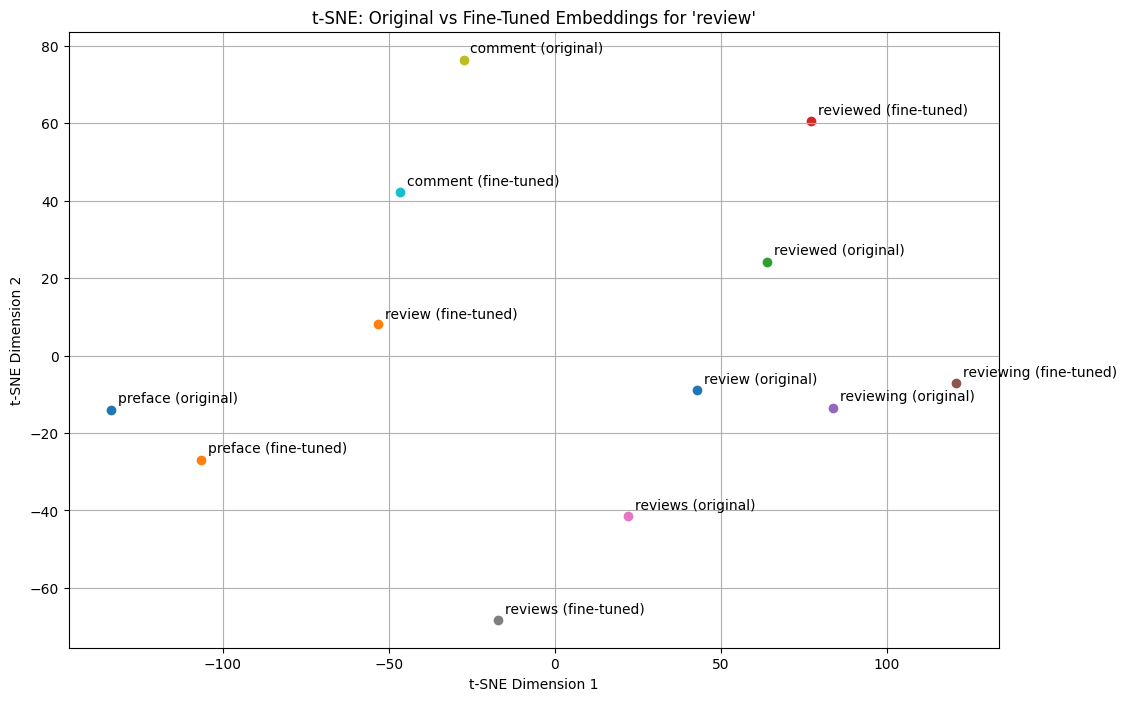

In [32]:
plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    plt.scatter(coords[i, 0], coords[i, 1])

    plt.annotate(
        label,
        (coords[i, 0], coords[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(
    "t-SNE: Original vs Fine-Tuned Embeddings for 'review'"
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)

plt.show()

### t-SNE Interpretation

The t-SNE visualization shows a visible change in the local embedding space before and after fine-tuning on IMDB reviews. The target word `review`, which was also the most-shifted target word according to the 300-dimensional cosine-similarity analysis, moves to a different location after fine-tuning. Several related words also change position, indicating that training on movie-review text adapted the pretrained embedding space toward domain-specific usage. Because t-SNE is a nonlinear 2D projection, the plot is used as a qualitative visualization of the shift; the original-to-fine-tuned cosine similarities provide the quantitative measure of embedding change.